<a href="https://colab.research.google.com/github/dimpalagrawal16/Hospital-Readmission-Prediction/blob/main/hospital_readmission_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Hospital Readmission Prediction

**Case Study:** Predict 30-day hospital readmission using Logistic Regression with L2 regularization.

This notebook uses the provided Kaggle dataset. It evaluates the model using ROC-AUC and discusses the clinical cost of false negatives versus false positives.

In [3]:
# Install required libraries if needed
!pip -q install pandas numpy scikit-learn matplotlib

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    roc_auc_score,
    classification_report,
    confusion_matrix,
    roc_curve
)

In [6]:
# Load the dataset
train_df = pd.read_csv("train_df.csv")
test_df = pd.read_csv("test_df.csv")

print("Training shape:", train_df.shape)
print("Testing shape:", test_df.shape)

print("\nColumns:")
print(train_df.columns.tolist())

print("\nTarget distribution:")
print(train_df["readmitted"].value_counts())

Training shape: (5000, 8)
Testing shape: (2000, 7)

Columns:
['age', 'gender', 'primary_diagnosis', 'num_procedures', 'days_in_hospital', 'comorbidity_score', 'discharge_to', 'readmitted']

Target distribution:
readmitted
0    4060
1     940
Name: count, dtype: int64


In [7]:
# Features and target

features = [
    "age",
    "gender",
    "primary_diagnosis",
    "num_procedures",
    "days_in_hospital",
    "comorbidity_score",
    "discharge_to"
]

X = train_df[features]
y = train_df["readmitted"]

categorical_features = [
    "gender",
    "primary_diagnosis",
    "discharge_to"
]

numerical_features = [
    "age",
    "num_procedures",
    "days_in_hospital",
    "comorbidity_score"
]

print("Features selected successfully!")
print("Number of features:", len(features))
print("Target:", "readmitted")

Features selected successfully!
Number of features: 7
Target: readmitted


In [8]:
# Preprocessing + Logistic Regression with L2 Regularization

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical_features
        ),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ]
)

model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "classifier",
            LogisticRegression(
                penalty="l2",
                C=1.0,
                max_iter=1000,
                random_state=42
            )
        )
    ]
)

print("Preprocessing and model created successfully!")
print("Regularization: L2")

Preprocessing and model created successfully!
Regularization: L2


In [9]:
# Split training data into training and validation sets

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Train the model
model.fit(X_train, y_train)

# Predict probabilities
y_prob = model.predict_proba(X_val)[:, 1]

# Convert probabilities to 0/1 predictions
y_pred = (y_prob >= 0.5).astype(int)

# Calculate ROC-AUC
auc = roc_auc_score(y_val, y_prob)

print("Model training completed successfully!")
print(f"ROC-AUC Score: {auc:.4f}")

Model training completed successfully!
ROC-AUC Score: 0.5067


In [10]:
# Classification report and confusion matrix

print("Classification Report:")
print(
    classification_report(
        y_val,
        y_pred,
        target_names=[
            "Not Readmitted",
            "Readmitted"
        ]
    )
)

# Confusion Matrix
cm = confusion_matrix(y_val, y_pred)

print("\nConfusion Matrix:")
print(cm)

# Extract values
tn, fp, fn, tp = cm.ravel()

print("\nTrue Negatives :", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives :", tp)

Classification Report:
                precision    recall  f1-score   support

Not Readmitted       0.81      1.00      0.90       812
    Readmitted       0.00      0.00      0.00       188

      accuracy                           0.81      1000
     macro avg       0.41      0.50      0.45      1000
  weighted avg       0.66      0.81      0.73      1000


Confusion Matrix:
[[812   0]
 [188   0]]

True Negatives : 812
False Positives: 0
False Negatives: 188
True Positives : 0


/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [11]:
# False Positive and False Negative Rates

fpr_value = fp / (fp + tn)
fnr_value = fn / (fn + tp)

print(f"False Positive Rate: {fpr_value:.4f}")
print(f"False Negative Rate: {fnr_value:.4f}")

False Positive Rate: 0.0000
False Negative Rate: 1.0000


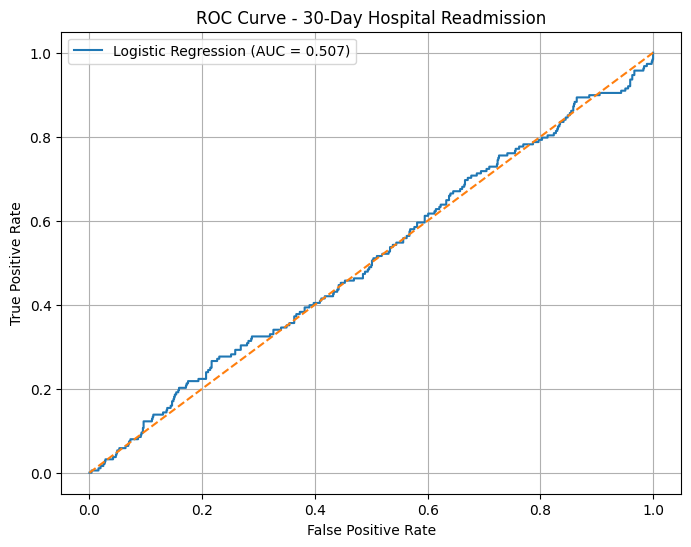

In [12]:
# ROC Curve

fpr, tpr, thresholds = roc_curve(y_val, y_prob)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f"Logistic Regression (AUC = {auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - 30-Day Hospital Readmission")
plt.legend()
plt.grid(True)
plt.show()

## Clinical Cost of Prediction Errors

**False Negative:** The model predicts that a patient is not at risk, but the patient is actually readmitted within 30 days. This can be clinically costly because a high-risk patient may miss additional follow-up or preventive intervention.

**False Positive:** The model predicts high readmission risk, but the patient is not readmitted. This can increase unnecessary follow-up, workload, and healthcare resource use.

In a clinical setting, the classification threshold can be adjusted when reducing false negatives is more important. The appropriate threshold should be selected using clinical costs and validation data.

In [16]:
# Create final Kaggle submission

model.fit(X, y)

test_prob = model.predict_proba(test_df[features])[:, 1]
test_pred = (test_prob >= 0.5).astype(int)

submission = pd.DataFrame({
    "Patient_ID": range(1, len(test_df) + 1),
    "readmitted": test_pred
})

submission.to_csv("submission.csv", index=False)

print("submission.csv created successfully!")
print(submission.head())
print("\nShape:", submission.shape)
print("Columns:", submission.columns.tolist())

submission.csv created successfully!
   Patient_ID  readmitted
0           1           0
1           2           0
2           3           0
3           4           0
4           5           0

Shape: (2000, 2)
Columns: ['Patient_ID', 'readmitted']


In [15]:
# Check the required Kaggle submission format

sample_submission = pd.read_csv("sample_submission.csv")

print("Sample submission:")
print(sample_submission.head())

print("\nRequired columns:")
print(sample_submission.columns.tolist())

print("\nRequired shape:")
print(sample_submission.shape)

print("\nOur submission:")
print(submission.head())

print("\nOur columns:")
print(submission.columns.tolist())

print("\nOur shape:")
print(submission.shape)

Sample submission:
   Patient_ID  readmitted
0           1           0
1           2           0
2           3           0
3           4           0
4           5           0

Required columns:
['Patient_ID', 'readmitted']

Required shape:
(2000, 2)

Our submission:
   readmitted
0           0
1           0
2           0
3           0
4           0

Our columns:
['readmitted']

Our shape:
(2000, 1)
